In [1]:
# Arrange and save Matplotlib figures.
import matplotlib.pyplot as plt
# Work with numeric arrays and cell masks.
import numpy as np
# Summarize cells and results in tables.
import pandas as pd

# Open count stores and run Scarf analyses.
import scarf
# Use Scarf plotting options and diagnostics.
import scarf.plotting as splt

# Keep routine logs and progress bars out of the results.
scarf.configure_output(level="WARNING", progress=False)

# Download the prepared example store.
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
# Open the count store for this analysis.
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
# Open the saved analysis that supplies the starting selections.
baseline = ds.pipeline.open(label="docs_default")
# Inspect the opened store's cells and features.
ds

Downloading bucket files: 56215324 / 56215324 complete

Downloading bytes: 56215324 / 56215324 complete

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

In [2]:
# Keep the cells used by the saved analysis.
cell_selection = baseline["analysis_cell_selection"]
# Keep the variable genes used by the saved analysis.
hvg_ref = baseline["highly_variable_features"]
# Use the cell metadata frozen with this analysis.
run_cells = baseline.cells
# Inspect the saved cell and gene selections.
{"cells": cell_selection, "genes": hvg_ref}

{'cells': ArtifactRef(datastore, kind='cell_selection', artifact_id='e6e222f7a568...'),
 'genes': ArtifactRef(assay='RNA', kind='feature_selection', artifact_id='cfd9446de944...')}

In [3]:
# Normalize counts over the selected features.
normalized = ds.run_normalization(cell_selection, hvg_ref)
# Reduce the normalized expression to principal components.
pca = ds.run_pca(normalized, dims=15)
# Inspect the PCA result that will supply neighbor coordinates.
pca

ArtifactRef(assay='RNA', kind='reduction', artifact_id='1f6b522d2aed...')

In [4]:
# Build the nearest-neighbor search index from the reduction.
ann_index = ds.build_ann_index(pca)
# Find neighbors of each cell in the reduced space.
neighbors = ds.query_neighbors(ann_index)
# Convert neighbor distances into weighted connectivity.
graph = ds.build_connectivity_map(neighbors)
# Inspect the saved connectivity graph.
graph

ArtifactRef(assay='RNA', kind='connectivity_map', artifact_id='c52919743a99...')

In [5]:
# Load a symmetric sparse graph for diagnostics.
loaded_graph = ds.load_graph(graph, symmetric=True)
# Check the number of cells and nonzero graph edges.
loaded_graph.shape, loaded_graph.nnz

((3948, 3948), 64990)

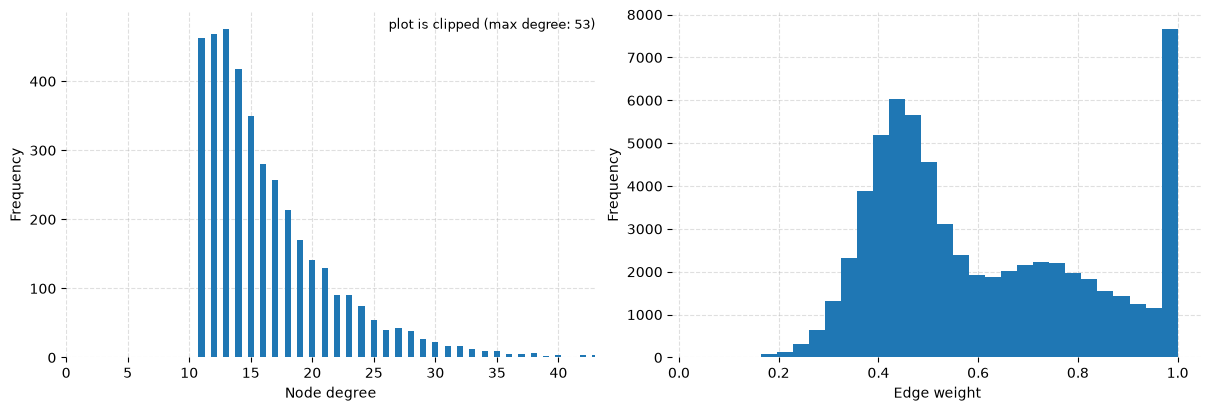

In [6]:
# Inspect graph degree and edge-weight distributions.
splt.graph_qc(loaded_graph)

In [7]:
# Count the neighbors connected to each cell.
degrees = np.asarray((loaded_graph != 0).sum(axis=0)).ravel()
# Summarize graph coverage and isolated cells.
pd.Series(
    {
        "active cells": int(loaded_graph.shape[0]),
        "isolated cells": int((degrees == 0).sum()),
        "median degree": float(np.median(degrees)),
        "min degree": int(degrees.min()),
        "max degree": int(degrees.max()),
    },
    name="graph coverage",
)

active cells      3948.0
isolated cells       0.0
median degree       15.0
min degree          11.0
max degree          53.0
Name: graph coverage, dtype: float64

In [8]:
# Align graph degrees with the same cells' quality measurements.
degree_vs_qc = pd.DataFrame(
    {
        "degree": degrees,
        "RNA_nCounts": run_cells.fetch("RNA_nCounts"),
        "RNA_nFeatures": run_cells.fetch("RNA_nFeatures"),
    }
)
# Check whether graph degree tracks the quality measurements.
degree_vs_qc.corr(numeric_only=True)

,degree,RNA_nCounts,RNA_nFeatures
degree,1.000000,0.077002,0.015492
RNA_nCounts,0.077002,1.000000,0.877195
RNA_nFeatures,0.015492,0.877195,1.000000


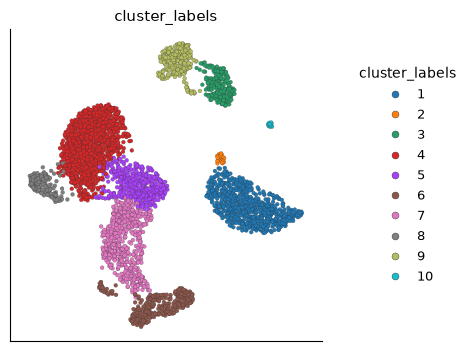

In [9]:
# Build starting coordinates for the embedding.
initialization = ds.build_embedding_initialization(pca)
# Calculate the UMAP coordinates from the graph.
umap = ds.run_umap(graph, initialization)
# Find groups of cells in the graph.
clusters = ds.run_leiden_clustering(graph, resolution=0.5)
# Read cluster labels in the selected cells' order.
cluster_values = np.asarray(ds.load_artifact(clusters)["values"][:])
# Color the graph-derived UMAP by its Leiden clusters.
ds.plots.embedding(layout=umap, color_by=clusters)

In [10]:
# Query the same index with 21 neighbors per cell.
neighbors_k21 = ds.query_neighbors(ann_index, k=21)
# Build connectivity for the 21-neighbor comparison.
graph_k21 = ds.build_connectivity_map(neighbors_k21)
# Check that the changed parameters produced a distinct result.
graph_k21 != graph

True

In [11]:
# Load the comparison graph with symmetric edges.
loaded_graph_k21 = ds.load_graph(graph_k21, symmetric=True)
# Compare the number of stored edges in the two graphs.
pd.Series(
    {
        "k=11 nnz": int(loaded_graph.nnz),
        "k=21 nnz": int(loaded_graph_k21.nnz),
    },
    name="edges",
)

k=11 nnz     64990
k=21 nnz    122020
Name: edges, dtype: int64

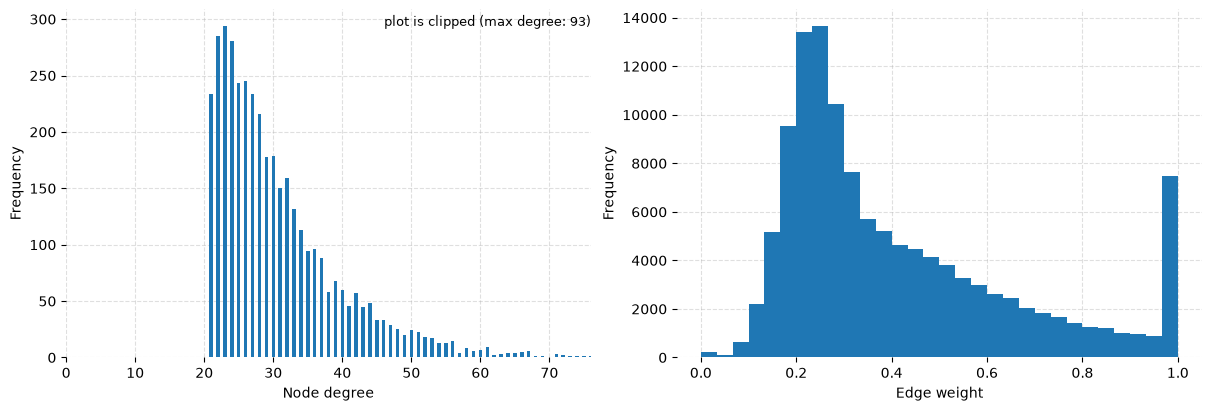

In [12]:
# Inspect graph degree and edge-weight distributions.
splt.graph_qc(loaded_graph_k21)

In [13]:
# Cluster the 21-neighbor graph at the same resolution.
clusters_k21 = ds.run_leiden_clustering(graph_k21, resolution=0.5)
# Read the comparison cluster labels.
cluster_values_k21 = np.asarray(ds.load_artifact(clusters_k21)["values"][:])
# Count cells in each reported category.
pd.Series(cluster_values_k21, name="cluster").value_counts().sort_index()

cluster
1      713
2       28
3      234
4     1301
5      397
6      319
7      535
8      145
9      261
10      15
Name: count, dtype: int64

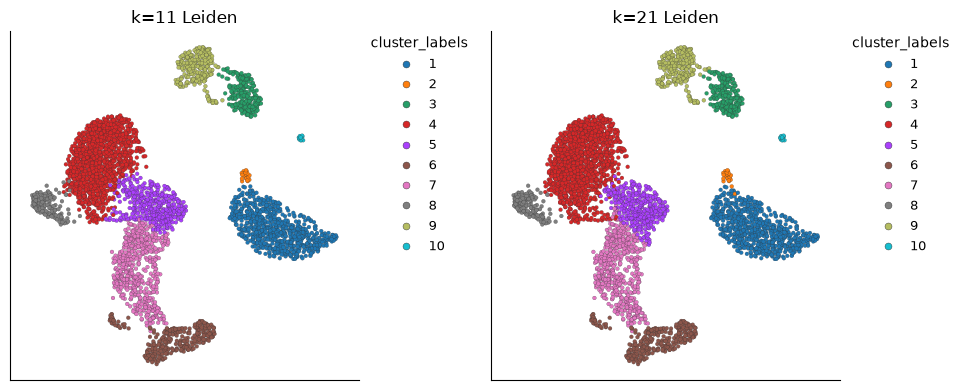

In [14]:
# Create axes for the comparison panels.
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
# Draw each result on its comparison axes.
for axis, cluster_ref, title in zip(
    axes,
    (clusters, clusters_k21),
    ("k=11 Leiden", "k=21 Leiden"),
    strict=True,
):
    # Compare the two clusterings on the same k=11 UMAP.
    ds.plots.embedding(
        layout=umap,
        color_by=cluster_ref,
        target=axis,
        show_titles=False,
        show=False,
    )
    # Label the panel with the result it shows.
    axis.set_title(title)
# Adjust spacing between the comparison panels.
figure.tight_layout()
# Display the completed comparison figure.
figure

In [15]:
# Count cells shared by each pair of cluster assignments.
pd.crosstab(
    pd.Series(cluster_values, name="k=11"),
    pd.Series(cluster_values_k21, name="k=21"),
)

k=21,1,2,3,4,5,6,7,8,9,10
k=11,,,,,,,,,,
1,713,3,0,0,0,0,0,0,0,0
2,0,25,0,0,0,0,0,0,0,0
3,0,0,234,0,0,0,0,0,5,0
4,0,0,0,1241,0,0,0,0,0,0
5,0,0,0,55,370,0,9,0,0,0
6,0,0,0,0,0,319,0,0,0,0
7,0,0,0,0,27,0,525,0,0,0
8,0,0,0,5,0,0,1,145,0,0
9,0,0,0,0,0,0,0,0,256,0
